# Choice Probability Tutorial

This tutorial examines the relationship between single-neuron activity and behavioral choices in a motion-discrimination task, building on the signal-detection-theory tutorial. The big idea: if a monkey's choices arise from the responses of neurons that signal the likelihood of one alternative versus another, then even at *zero coherence* (no real motion signal), the response of a single neuron on a given trial should be predictive of the monkey's choice on that trial. The strength of that association is the *choice probability*.

- M. N. Shadlen, Cold Spring Harbor 1998; updated MRC 2010, EAC 2022
- JS translated to Python in 2026 (with edited comments)

In [1]:
import numpy as np
from sklearn.metrics import roc_auc_score
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# random seed for consistent outputs
rng = np.random.default_rng(0)

## Modeling MT-like neurons

We model the firing rate of a direction-selective neuron as linear in motion coherence:

$$\langle r\rangle = \text{spikes\_at\_0coh} + \text{slope} \cdot \text{coh}$$

and the spike-count variance as $\text{Fano} \cdot \langle r\rangle$ (proportional to the mean — the Poisson-like variability seen in cortex that you would measure if you showed the same stimulus over and over again.  See the GamSpikeTrainTutorial).

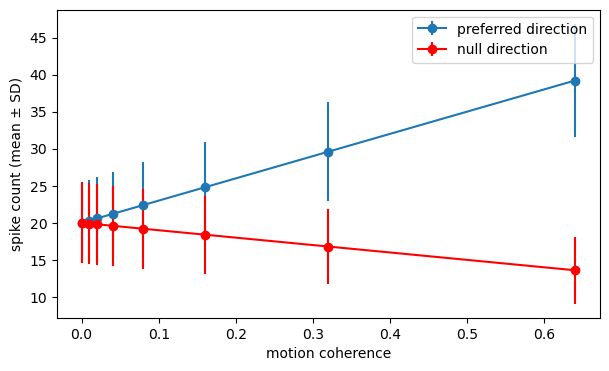

In [2]:
spikes_at_coh0 = 20.0       # baseline firing with 0% coherent motion
slope_pref = 30.0           # spikes/sec increase per unit coherence (pref direction)
slope_null = -10.0          # spikes/sec decrease per unit coherence (null direction)
fano = 1.5                  # noise
duration = 1.0              # sampling duration

cohs = np.array([0, 0.01, 0.02, 0.04, 0.08, 0.16, 0.32, 0.64])
mean_pref = spikes_at_coh0 + slope_pref * cohs
mean_null = spikes_at_coh0 + slope_null * cohs

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(cohs, mean_pref, yerr=np.sqrt(fano * mean_pref),
            fmt='o-', label='preferred direction')
ax.errorbar(cohs, mean_null, yerr=np.sqrt(fano * mean_null),
            fmt='o-', color='r', label='null direction')
ax.set(xlabel='motion coherence', ylabel='spike count (mean ± SD)')
ax.legend()
plt.show()

## Trial-by-trial choices at 0% coherence

At 0 coherence, the UP and DOWN preferring neurons have the same mean response. But trial-to-trial fluctuations might still differ — and if the monkey reads out the *larger* response, then the response of the UP neuron will be slightly larger on UP-choice trials than on DOWN-choice trials, even at 0 coherence.

In [4]:
def simulate_counts(mean_up, mean_dn, n_trials, fano, rng):
    return (rng.normal(mean_up, np.sqrt(fano * mean_up), n_trials),
            rng.normal(mean_dn, np.sqrt(fano * mean_dn), n_trials))

n_trials = 5000
counts_up, counts_dn = simulate_counts(spikes_at_coh0, spikes_at_coh0,
                                       n_trials, fano, rng)

choices_up = counts_up > counts_dn
choices_dn = ~choices_up

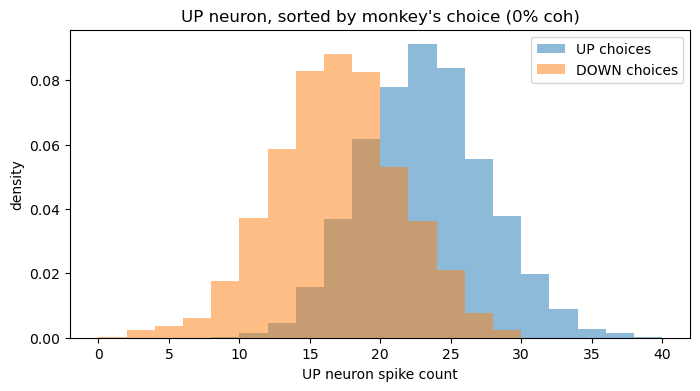

UP neuron mean on UP choices:   23.23
UP neuron mean on DOWN choices: 16.89


In [5]:
bins = np.arange(0, 42, 2)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(counts_up[choices_up], bins=bins, density=True, alpha=0.5,
        label='UP choices')
ax.hist(counts_up[choices_dn], bins=bins, density=True, alpha=0.5,
        label='DOWN choices')
ax.set(xlabel='UP neuron spike count', ylabel='density',
       title='UP neuron, sorted by monkey\'s choice (0% coh)')
ax.legend()
plt.show()

print(f'UP neuron mean on UP choices:   {counts_up[choices_up].mean():.2f}')
print(f'UP neuron mean on DOWN choices: {counts_up[choices_dn].mean():.2f}')

## Choice probability as area under the ROC

Given the two distributions of UP-neuron counts (one for each choice), how well could an ideal observer guess the choice from the count? That's the area under the ROC — the **choice probability**:

In [6]:
y_true = choices_up.astype(int)        # 1 if monkey chose UP
CP = roc_auc_score(y_true, counts_up)  # how well does count predict UP-choice?
print(f'Choice probability (single UP neuron, no pooling): {CP:.3f}')

Choice probability (single UP neuron, no pooling): 0.842


About 0.85 — a very strong association. But measured choice probabilities in MT are more like 0.55–0.60. Why is the model so far off? Because the monkey almost certainly isn't relying on a single neuron.

## Pooling many neurons (independent)

Suppose the monkey averages the responses of `pool_size` independent neurons in each pool:

In [7]:
def simulate_pool_independent(mean_up, mean_dn, n_trials, pool_size, fano, rng):
    sd_up = np.sqrt(fano * mean_up)
    sd_dn = np.sqrt(fano * mean_dn)
    counts_up = rng.normal(mean_up, sd_up, (n_trials, pool_size))
    counts_dn = rng.normal(mean_dn, sd_dn, (n_trials, pool_size))
    return counts_up, counts_dn

pool_size = 50
counts_up, counts_dn = simulate_pool_independent(
    spikes_at_coh0, spikes_at_coh0, n_trials, pool_size, fano, rng)

choices_up = counts_up.mean(axis=1) > counts_dn.mean(axis=1)

# choice probability for each neuron, then average
CPs = [roc_auc_score(choices_up.astype(int), counts_up[:, k])
       for k in range(pool_size)]
print(f'Mean CP across {pool_size} independent UP-pool neurons: '
      f'{np.mean(CPs):.3f}')

Mean CP across 50 independent UP-pool neurons: 0.545


With 50 *independent* neurons, the CP drops to ~0.55. So far so good — but there's a catch: more independent neurons also make the *behavior* more sensitive (lower threshold) than is observed in real monkeys. We'll see this below.

## Correlated pools

Real cortical neurons have weak but consistent positive noise correlations ("r-bar" around 0.1–0.2). The effect is twofold:
1. Pooling **stops improving sensitivity** beyond a certain number of neurons.
2. Each neuron retains a non-trivial association with the choice, so CP doesn't shrink to chance.

We generate correlated responses by drawing standard Gaussians and multiplying by the Cholesky factor of the target covariance matrix:

In [8]:
def cholesky_for_uniform_r(pool_size, rbar):
    """Cholesky factor of a correlation matrix with off-diagonal entries = rbar."""
    C = rbar * np.ones((pool_size, pool_size)) + (1 - rbar) * np.eye(pool_size)
    return np.linalg.cholesky(C)

def simulate_pool_correlated(mean_up, mean_dn, n_trials, pool_size, fano, rbar, rng):
    L = cholesky_for_uniform_r(pool_size, rbar)
    sd_up = np.sqrt(fano * mean_up)
    sd_dn = np.sqrt(fano * mean_dn)
    z_up = rng.standard_normal((n_trials, pool_size)) @ L.T
    z_dn = rng.standard_normal((n_trials, pool_size)) @ L.T
    return (mean_up + sd_up * z_up,
            mean_dn + sd_dn * z_dn)

rbar = 0.2
counts_up, counts_dn = simulate_pool_correlated(
    spikes_at_coh0, spikes_at_coh0, n_trials, pool_size, fano, rbar, rng)

# confirm pairwise correlation
C = np.corrcoef(counts_up, rowvar=False)
off_diag = C[~np.eye(pool_size, dtype=bool)]
print(f'Mean pairwise r in UP pool: {off_diag.mean():.3f}')

choices_up = counts_up.mean(axis=1) > counts_dn.mean(axis=1)
CPs = [roc_auc_score(choices_up.astype(int), counts_up[:, k])
       for k in range(pool_size)]
print(f'Mean CP with rbar={rbar}: {np.mean(CPs):.3f}')

Mean pairwise r in UP pool: 0.196
Mean CP with rbar=0.2: 0.644


Now we have a measurable choice probability (>0.5) that doesn't disappear as we add more neurons — closer to the experimental observation.

## Sensitivity (psychometric function) for single vs. pooled-with-correlation models

We're now ready to ask: does this same model also predict the right psychophysical threshold? Compute a psychometric function for both the single-neuron model and the pooled-correlated model.

In [9]:
def weibull_pc(x, threshold, slope):
    return 1 - 0.5 * np.exp(-(x / threshold) ** slope)

def fit_weibull(cohs, p_correct, n_trials):
    p0 = [0.1, 1.5]
    weights = np.sqrt(n_trials)
    popt, _ = curve_fit(weibull_pc, cohs[cohs > 0], p_correct[cohs > 0],
                        p0=p0, sigma=1/weights[cohs > 0], maxfev=10000,
                        bounds=([1e-3, 0.5], [1.0, 5.0]))
    return popt

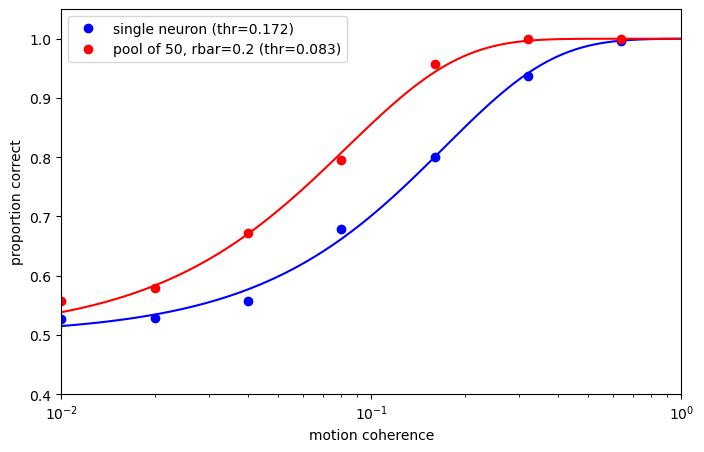

In [10]:
n_trials_each = 1000

p_single = np.zeros_like(cohs)
for i, c in enumerate(cohs):
    mu_up = duration * (spikes_at_coh0 + slope_pref * c)
    mu_dn = duration * (spikes_at_coh0 + slope_null * c)
    up, dn = simulate_counts(mu_up, mu_dn, n_trials_each, fano, rng)
    p_single[i] = np.mean(up > dn)

p_pooled = np.zeros_like(cohs)
pool_size = 50
for i, c in enumerate(cohs):
    mu_up = duration * (spikes_at_coh0 + slope_pref * c)
    mu_dn = duration * (spikes_at_coh0 + slope_null * c)
    up, dn = simulate_pool_correlated(mu_up, mu_dn, n_trials_each,
                                      pool_size, fano, rbar, rng)
    p_pooled[i] = np.mean(up.mean(axis=1) > dn.mean(axis=1))

n_arr = np.full_like(cohs, n_trials_each, dtype=float)
thr_single, slope_single = fit_weibull(cohs, p_single, n_arr)
thr_pooled, slope_pooled = fit_weibull(cohs, p_pooled, n_arr)

xs = np.logspace(-2, 0, 100)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cohs, p_single, 'bo', label=f'single neuron (thr={thr_single:.3f})')
ax.plot(xs, weibull_pc(xs, thr_single, slope_single), 'b')
ax.plot(cohs, p_pooled, 'ro',
        label=f'pool of {pool_size}, rbar={rbar} (thr={thr_pooled:.3f})')
ax.plot(xs, weibull_pc(xs, thr_pooled, slope_pooled), 'r')
ax.set(xscale='log', xlabel='motion coherence',
       ylabel='proportion correct',
       xlim=(0.01, 1), ylim=(0.4, 1.05))
ax.legend()
plt.show()

Pooling lowers the threshold (better sensitivity), but only modestly because of the noise correlations — exactly what's seen experimentally.

## Takeaway

A single MT-like neuron's responses are correlated with the monkey's choices on a trial-by-trial basis. The simplest "single neuron" model predicts choice probability of ~0.86 (much higher than measured) and a threshold close to the neurometric threshold. Pooling lots of independent neurons drops the CP to chance but predicts unrealistically low thresholds. With *weak positive noise correlations* the pool both retains a measurable choice probability *and* fails to improve sensitivity beyond what the single neuron achieves — reproducing both experimental constraints with the same decision rule.